# K-Nearest Neighbors

1. you move to a new city and want to decide whether a resturant is good?
2. How?
3. Check review
4. Ask nearby people
5. see what friends recommendations
6. KNN also ask its nearest neighbors before making a prediction.


2. K-Nearest neighbors (KNN) is a supervised machine learning algorithm
- Used for:
 - Classification 
 - Regression
- It predicts the output by loading at the K nearest data points.

- **Example**
  - A new student join a class.
    - Nearby student
      - A-> Science
      - B -> Science 
      - C-> Commerce
    - predict -> commerce
- **Example2**
   - Movie Recommendation
   - Himank-> Action
   - Mihika -> Thriller
   - Shaurya -> Action
   - Saurab-> Action

# Where KNN is Used: 
  - Email spam detection
  - Disease prediction
  - Student will pass or not
  - Banking(Credit approval)
  - face recognition

# Types Of Problems solved
 - 1. Classification-:
    - output is category
    - ex->> spam or not spam
    - cancer or No cancer
    - male or female

- 2. Regression:
   - Output is continuous value
   - ex->> House price
   - Salary prediction
   - temperature predict

- 3. why??
   - suppose there is a new point
   - there are many old points
   - the closed one
   - because nearby objects usually have similar properties.

- 4. Distance Measure ..............??
   - Eucludiean
   - d= sqrt((x2-x1))^2 +((y2-y1)^2)
   - point A - (2,3)
   - point b - (5,7)
   - Distance = sqrt((5-2)^2 + (7-3)^2) = 9+ 16 =25 ->> 5


- 5. Manhattan Distance
    - like walking on road
    - can not move diagonally
    - form = |x2-x1| + |y2- y1|

- 6. Hamming Distance
    - used for categorical data
    - Binary Data
    - ex ->> 1011110 ->> 10011
    - Different bits = Hamming disatnce

- K means number of nearest neighbors
   - K =3 : Look at nearest 3 neighbors
   - K=5: Look at nearest 5 neighbors

- Example:
  - Suppose : red,red, blue, k=3
  - majority: red
  - predict : red

4. Choosing K?
 - small k:
 - advantage: sensitive,captures local pattern
 - disadvantages: Overfitting, Noise affects prediction

- Large K:
   - advantage:Stable, Less noise
   - disadvantage : Underfitting

- IMP: Golden rules:
- K = sqrt(N)
- N: No. of samples
- examples : 100 samples = sqrt(N) = sqrt(100) =10
-K =10, then use cross validation to choose the best K

# Working
1. Choose K
2. Calculate Distance
3. Find K nearest neighbors
4. Voting
5. predict our class

- Suppose K= 3
- neighbor : A
- neighbor : B
- neighbor : A
- neighbor : C
- Predict A


2. Neighbors: cat

   Neighbors: Dog 

   Neighbors: Dog
   
   Neighbors: Dog
   - Predict : Dog

# Dataset
- height: 160,165,170,180,185
- weight: 55,60,65,90,95
- class:  fit,fit,fit,unfit,unfit

- New Person:
- height is 172
- weight is 68
- class? fit ya unfit??


- predict: Fit


# Feature Scalling?

- age: 20
- salary: 20000
- which salary feature dominates
- salary
- Therefore always scale data before KNN

# KNN Lazy learner or fast learner?? Why??

KNN is Lazy learner because -:
- because it does not learn during training
- it stores data and predicts only when a sample arrives

# KNN :
- Lazy learner, it does not requires training, and it works on distance based so slow prediction.

# Logistic Regression
 - Eager learner, it requires a training and it is based on probability and fast prediction.

## Practice


#### Workflow

 - Import libraries
 - Load dataset
 - Explore dataset
 - Split feature and target
 - train-test split
 - feature scaling
 - create KNN model
 - Train model
 - Prediction
 - Evaluate model
 - (Accuracy, Precision Recall, f1 Score, classification_report)
 - Predict New Data
 - find best K value


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score

In [15]:
cancer = load_breast_cancer()

In [16]:
df=pd.DataFrame(
    cancer.data,
    columns= cancer.feature_names
)

In [17]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
df['Target'] = cancer.target

In [19]:
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [20]:
df.shape

(569, 31)

In [21]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64

In [22]:
print(df['Target'].value_counts())

Target
1    357
0    212
Name: count, dtype: int64


In [23]:
x= df.drop('Target',axis=1) # Independent variable also called feature
y= df['Target'] # Depenndent variable also called target variable

In [62]:
x_train,x_test,y_train,y_test= train_test_split(
    x,y,
    test_size=0.2,
    random_state = 40,
    stratify=y
)

In [63]:
print(x_train.shape)

(455, 30)


In [64]:
print(x_test.shape)

(114, 30)


In [65]:
scaler = StandardScaler()

In [66]:
x_train = scaler.fit_transform(x_train)

In [67]:
x_test = scaler.transform(x_test) # Use transform instead of fit_transform to avoid data leakage

In [68]:
model = KNeighborsClassifier(n_neighbors =5)

In [69]:
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [70]:
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [71]:
y_pred = model.predict(x_test)

In [72]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [73]:
comparison.head(5)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1


In [74]:
accuracy = accuracy_score(y_test,y_pred)

In [75]:
accuracy

0.9912280701754386

In [76]:
precision = precision_score(y_test,y_pred)

In [77]:
precision

0.9863013698630136

In [78]:
confusion_mat = confusion_matrix(y_test,y_pred)

In [79]:
confusion_mat

array([[41,  1],
       [ 0, 72]])

In [80]:
recall =recall_score(y_test,y_pred)

In [81]:
recall

1.0

In [82]:
f1 = f1_score(y_test,y_pred) ## F1 score is the harmonic mean of precision and recall. It is a measure of a test's accuracy. It considers both the precision and the recall of the test to compute the score. The F1 score can be interpreted as a weighted average of the precision and recall, where an F1 score reaches its best value at 1 (perfect precision and recall) and worst at 0.

In [83]:
f1

0.993103448275862

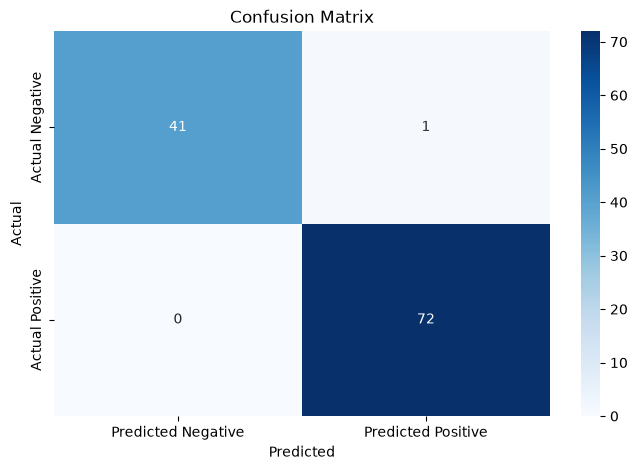

In [84]:
plt.figure(figsize=(8,5))
sns.heatmap(confusion_mat, annot=True , fmt='d',cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [85]:
classification_rep = classification_report(y_test,y_pred)

In [86]:
print(classification_rep)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [88]:
sample = x.iloc[[0]]
sam = scaler.transform(sample)
prediction = model.predict(sam)

print("Predicted Class:", prediction[0])
print("Actual Class:",y.iloc[0])

Predicted Class: 0
Actual Class: 0


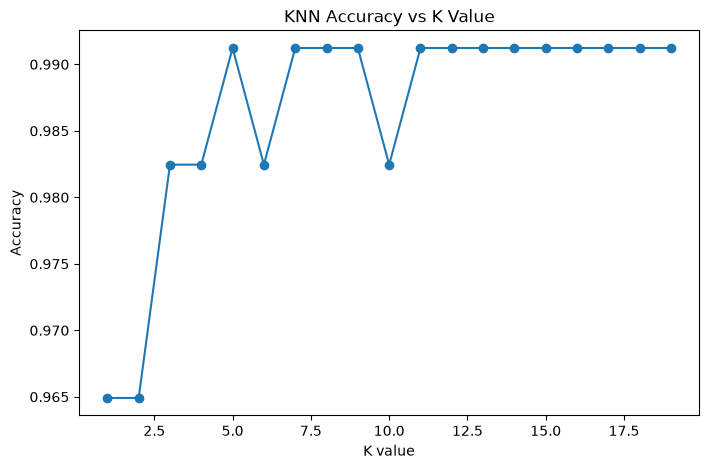

In [100]:
acc_score =[]
for k in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    score = accuracy_score(y_test,y_pred)
    acc_score.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(1,20), acc_score, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.show()

# Practice


### dataset iris

In [102]:
from sklearn.datasets import load_iris

In [103]:
iris = load_iris()

In [149]:
df= pd.DataFrame(
    iris.data,
    columns= iris.feature_names
)

In [151]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [150]:
df['Target']= iris.target

In [108]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [110]:
df.shape

(150, 5)

In [111]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

In [112]:
df.duplicated().sum()

np.int64(1)

In [113]:
print(df['Target'].value_counts())

Target
0    50
1    50
2    50
Name: count, dtype: int64


In [114]:
x= df.drop('Target',axis=1) # Independent variable also called feature
y= df['Target'] # Depenndent variable also called target variable

In [115]:
x_train,x_test,y_train,y_test= train_test_split(
    x,y,
    test_size=0.15,
    random_state = 44,
    stratify=y
)

In [116]:
print(x_train.shape)

(127, 4)


In [117]:
print(x_test.shape)

(23, 4)


In [118]:
scaler = StandardScaler()

In [119]:
x_train = scaler.fit_transform(x_train)

In [120]:
x_test = scaler.transform(x_test) # Use transform instead of fit_transform to avoid data leakage

In [121]:
model = KNeighborsClassifier(n_neighbors =5)

In [122]:
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [123]:
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [124]:
y_pred = model.predict(x_test)

In [125]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [126]:
comparison.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,2,2
4,2,2
5,1,1
6,2,2
7,0,0
8,2,2
9,1,1


In [127]:
accuracy = accuracy_score(y_test,y_pred)

In [128]:
accuracy

0.9565217391304348

In [132]:
precision= precision_score(y_test,y_pred,average='weighted') # Use average='weighted' for multi-class classification to account for label imbalance

In [133]:
precision

0.9613526570048309

In [134]:
confusion_mat = confusion_matrix(y_test,y_pred)

In [135]:
confusion_mat

array([[8, 0, 0],
       [0, 8, 0],
       [0, 1, 6]])

In [137]:
f1 = f1_score(y_test,y_pred,average='weighted') ## F1 score is the harmonic mean of precision and recall. It is a measure of a test's accuracy. It considers both the precision and the recall of the test to compute the score. The F1 score can be interpreted as a weighted average of the precision and recall, where an F1 score reaches its best value at 1 (perfect precision and recall) and worst at 0.

In [138]:
f1

0.9561282707062758

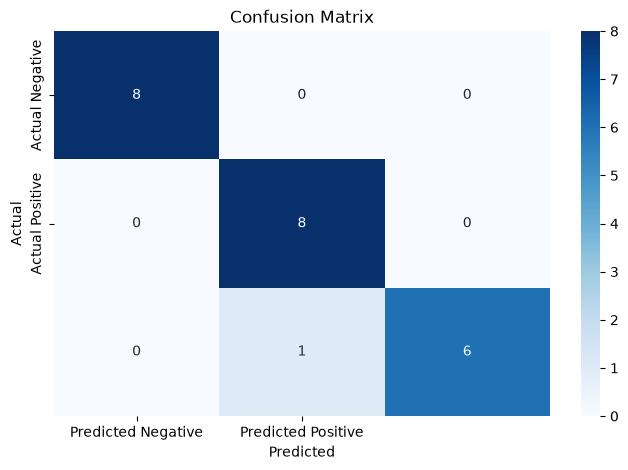

In [139]:
plt.figure(figsize=(8,5))
sns.heatmap(confusion_mat, annot=True , fmt='d',cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [140]:
classification_rep = classification_report(y_test,y_pred)

In [142]:
print(classification_rep)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.89      1.00      0.94         8
           2       1.00      0.86      0.92         7

    accuracy                           0.96        23
   macro avg       0.96      0.95      0.95        23
weighted avg       0.96      0.96      0.96        23



In [143]:
sample = x.iloc[[0]]
sam = scaler.transform(sample)
prediction = model.predict(sam)

print("Predicted Class:", prediction[0])
print("Actual Class:",y.iloc[0])

Predicted Class: 0
Actual Class: 0


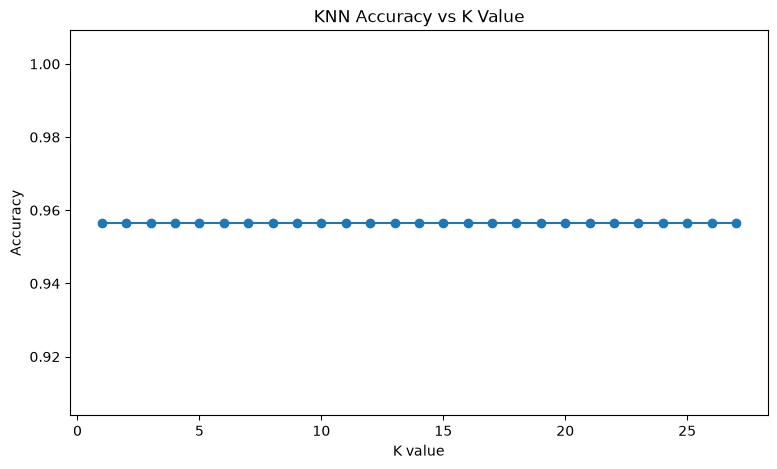

In [147]:
acc_score =[]
for k in range(1, 28):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    score = accuracy_score(y_test,y_pred)
    acc_score.append(score)

plt.figure(figsize=(9,5))
plt.plot(range(1,28), acc_score, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.show()